# LOH.1 + a Q operator = LOH.3 ?

Forward test of the constant-Q operator: take the elastic LOH.1 stations, attenuate
them by hand, and compare with the LOH.3 stations the engine attenuated itself.

Nothing is run here. The data come from the other notebooks in this folder:

| file | written by | model | sigma | dt |
|---|---|---|---|---|
| `sta01.npz`, `sta02.npz`, `sta03.npz` | `example_LOH1_gf.ipynb` | LOH.1, elastic | 0.06 s | 0.005 s |
| `loh3_sta01.npz`, `loh3_sta02.npz`, `loh3_sta03.npz` | `LOH3_greens_functions.ipynb` | LOH.3, with Q | 0.05 s | 0.004 s |

Run those two first.

In [1]:
import os
import sys

_repo = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
if _repo not in sys.path:
    sys.path.insert(0, _repo)

import matplotlib.pyplot as plt
import numpy as np

from shakermaker.station import Station

# LOH.3 layers (for the straight-ray t* only)
thk = (1.0, 0.0)
vs = (2.000, 3.464)
qs = (40.0, 69.3)

# source time functions of the two runs
sigma_1, t0_1 = 0.06, 0.36     # LOH.1, example_LOH1_gf.ipynb
sigma_3, t0_3 = 0.05, 0.30     # LOH.3, LOH3_greens_functions.ipynb

dt = 0.005                     # common grid (the LOH.1 one)
tplot = 15.0
fmax_fit = 10.0                # FK taper starts at 0.05/dt = 10 Hz for dt = 0.005

stations = ["sta01", "sta02", "sta03"]


    ▄████████     ▄█    █▄     ▄████████     ▄█   ▄█▄    ▄████████    ▄████████
    ███    ███   ███    ███    ███    ███    ███ ▄███▀   ███    ███   ███    ███
    ███    █▀    ███    ███    ███    ███    ███▐██▀     ███    █▀    ███    ███
    ███         ▄███▄▄▄▄███▄▄  ███    ███   ▄█████▀     ▄███▄▄▄      ▄███▄▄▄▄██▀
  ▀███████████  ▀███▀▀▀▀███▀  ▀███████████  ▀█████▄    ▀▀███▀▀▀     ▀▀███▀▀▀▀▀
           ███   ███    ███    ███    ███    ███▐██▄     ███    █▄   ▀███████████
     ▄█    ███   ███    ███    ███    ███    ███ ▀███▄   ███    ███   ███    ███
   ▄████████▀    ███    █▀     ███    █▀     ███   ▀█▀   ██████████   ███    ███
                                                                      ███    ███

         ▄▄▄▄███▄▄▄▄      ▄████████    ▄█   ▄█▄    ▄████████    ▄████████
       ▄██▀▀▀███▀▀▀██▄   ███    ███    ███ ▄███▀   ███    ███   ███    ███
       ███   ███   ███   ███    ███    ███▐██▀     ███    █▀    ███    ███
       ███   ███   ███   ███    ███   ▄█████▀  

## 1. Load

In [2]:
def load(npz):
    sta = Station()
    sta.load(npz)
    z, e, n, t = sta.get_response()
    return sta.x, np.asarray(t), np.asarray(z), np.asarray(e), np.asarray(n)


loh1, loh3 = {}, {}
for name in stations:
    loh1[name] = load(f"{name}.npz")
    loh3[name] = load(f"loh3_{name}.npz")
    x1, x3 = loh1[name][0], loh3[name][0]
    assert np.allclose(x1, x3), f"{name}: LOH.1 at {x1}, LOH.3 at {x3}"
    print(f"{name} at {x1}   LOH.1 dt = {loh1[name][1][1] - loh1[name][1][0]:.4f}   "
          f"LOH.3 dt = {loh3[name][1][1] - loh3[name][1][0]:.4f}")

Loading station data from npzfilename=sta01.npz
Data=NpzFile 'sta01.npz' with keys: _x, _metadata, _observers, _internal, _initialized...
Loading station data from npzfilename=loh3_sta01.npz
Data=NpzFile 'loh3_sta01.npz' with keys: _x, _metadata, _observers, _internal, _initialized...
sta01 at [8. 8. 0.]   LOH.1 dt = 0.0050   LOH.3 dt = 0.0040
Loading station data from npzfilename=sta02.npz
Data=NpzFile 'sta02.npz' with keys: _x, _metadata, _observers, _internal, _initialized...
Loading station data from npzfilename=loh3_sta02.npz
Data=NpzFile 'loh3_sta02.npz' with keys: _x, _metadata, _observers, _internal, _initialized...
sta02 at [6. 8. 0.]   LOH.1 dt = 0.0050   LOH.3 dt = 0.0040
Loading station data from npzfilename=sta03.npz
Data=NpzFile 'sta03.npz' with keys: _x, _metadata, _observers, _internal, _initialized...
Loading station data from npzfilename=loh3_sta03.npz
Data=NpzFile 'loh3_sta03.npz' with keys: _x, _metadata, _observers, _internal, _initialized...
sta03 at [4.  4.  0.5]

## 2. Put LOH.3 on the LOH.1 source time function

The two runs differ in the Gaussian STF as well as in Q. The STF is a factor in the
spectrum, and for the ShakerMaker Gaussian it is

$$G(f) = e^{-2\pi^2 f^2 \sigma^2}\, e^{-i 2\pi f t_0}$$

so multiplying the LOH.3 spectrum by $G_{0.06}/G_{0.05}$ gives LOH.3 as if it had been run
with the LOH.1 source. That ratio only damps, so nothing is amplified. After that, both
are resampled to the same time grid and Q is the only difference left.

In [3]:
def to_loh1_stf(x, dt_x):
    f = np.fft.rfftfreq(len(x), dt_x)
    ratio = (np.exp(-2 * np.pi ** 2 * f ** 2 * (sigma_1 ** 2 - sigma_3 ** 2))
             * np.exp(-1j * 2 * np.pi * f * (t0_1 - t0_3)))
    return np.fft.irfft(np.fft.rfft(x) * ratio, len(x))


t = np.arange(0, 16.0, dt)
elastic, attenuated = {}, {}
for name in stations:
    _, t1, z1, e1, n1 = loh1[name]
    _, t3, z3, e3, n3 = loh3[name]
    dt3 = t3[1] - t3[0]
    elastic[name] = {c: np.interp(t, t1, x) for c, x in zip("zen", (z1, e1, n1))}
    attenuated[name] = {c: np.interp(t, t3, to_loh1_stf(x, dt3))
                        for c, x in zip("zen", (z3, e3, n3))}

## 3. Fourier: read `t*` off the two spectra

Constant Q multiplies the spectrum by `exp(-pi f t*)`, so

$$\ln \frac{|U_{LOH.3}(f)|}{|U_{LOH.1}(f)|} = -\pi\,t^*\,f$$

is a straight line through the origin. The three components are combined as
root-sum-square amplitude spectra and smoothed over 0.6 Hz before taking the ratio,
because the ratio spikes at every spectral null. The fit runs from 0.3 to 10 Hz: above
10 Hz the FK taper of the LOH.1 run (`dt = 0.005`) starts.

sta01  t* fit =  54.8 ms   ray =  95.7 ms   intercept = -0.321
sta02  t* fit =  62.5 ms   ray =  85.0 ms   intercept = -0.169
sta03  t* fit =  36.7 ms   ray =  40.6 ms   intercept = -0.109


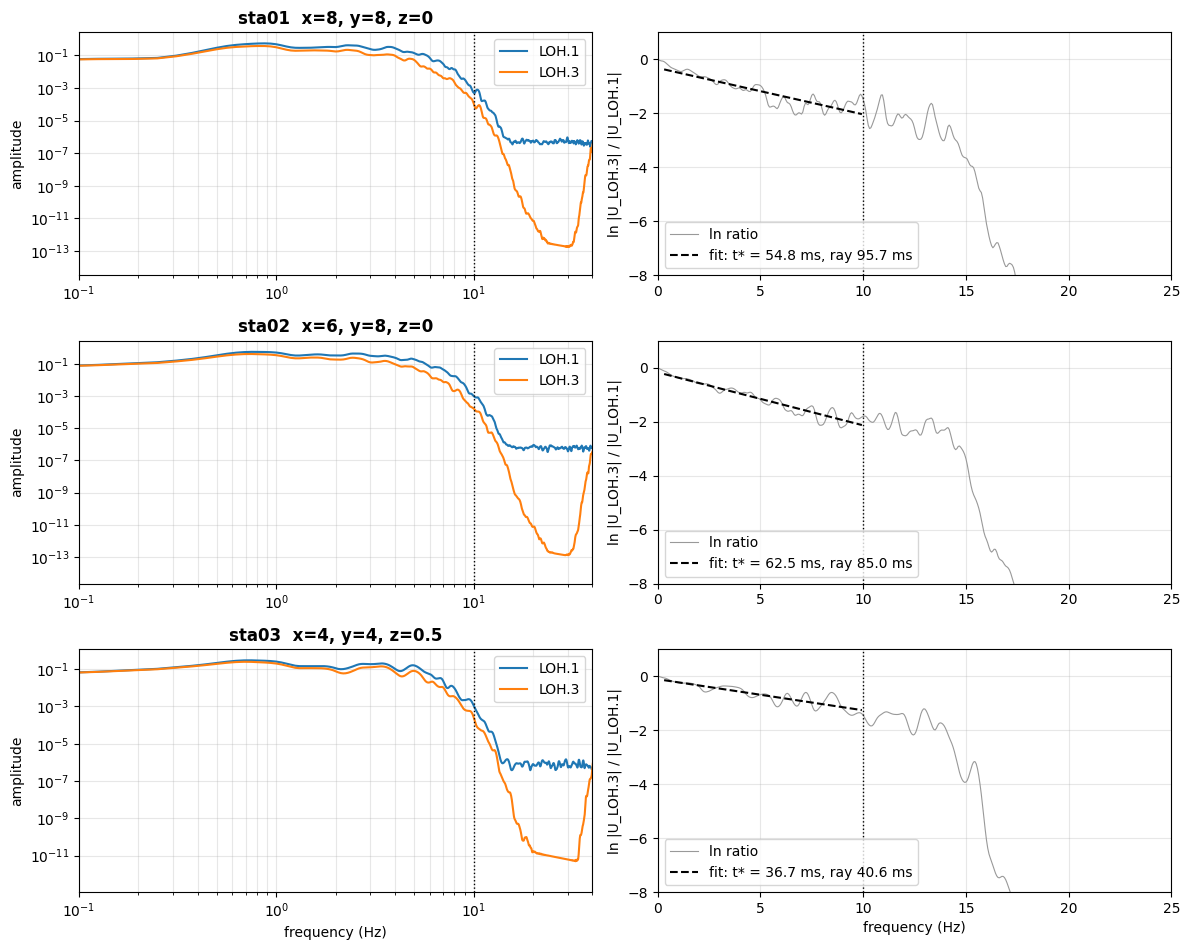

In [4]:
freq = np.fft.rfftfreq(len(t), dt)
win = np.hanning(len(t))


def amp(d):
    return np.sqrt(sum(np.abs(np.fft.rfft(d[c] * win)) ** 2 for c in "zen"))


def smooth(x, width=0.6):
    return np.array([x[np.abs(freq - f) <= width / 2].mean() for f in freq])


def tstar_ray(x):
    north, east, depth = x
    length = np.sqrt(north ** 2 + east ** 2 + (2.0 - depth) ** 2)
    frac_half = (2.0 - thk[0]) / (2.0 - depth)
    return (length * frac_half / (vs[1] * qs[1])
            + length * (1 - frac_half) / (vs[0] * qs[0]))


band = (freq > 0.3) & (freq < fmax_fit)
tstar = {}

fig, axes = plt.subplots(len(stations), 2, figsize=(12, 3.2 * len(stations)))
for row, name in zip(axes, stations):
    a1 = smooth(amp(elastic[name]))
    a3 = smooth(amp(attenuated[name]))
    ratio = np.log(a3[band] / a1[band])
    slope, intercept = np.polyfit(freq[band], ratio, 1)
    tstar[name] = -slope / np.pi
    x = loh1[name][0]

    row[0].loglog(freq[1:], a1[1:] * dt, label="LOH.1")
    row[0].loglog(freq[1:], a3[1:] * dt, label="LOH.3")
    row[0].axvline(fmax_fit, color="k", ls=":", lw=1)
    row[0].set_xlim(0.1, 40)
    row[0].set_ylabel("amplitude")
    row[0].set_title(f"{name}  x={x[0]:g}, y={x[1]:g}, z={x[2]:g}", fontweight="bold")
    row[0].grid(alpha=0.3, which="both")
    row[0].legend()

    lr = np.log(a3[1:] / a1[1:])
    row[1].plot(freq[1:], lr, color="0.6", lw=0.8, label="ln ratio")
    row[1].plot(freq[band], slope * freq[band] + intercept, "k--",
                label=f"fit: t* = {1000 * tstar[name]:.1f} ms, "
                      f"ray {1000 * tstar_ray(x):.1f} ms")
    row[1].axvline(fmax_fit, color="k", ls=":", lw=1)
    row[1].set_xlim(0, 25)
    row[1].set_ylim(-8, 1)
    row[1].set_ylabel("ln |U_LOH.3| / |U_LOH.1|")
    row[1].grid(alpha=0.3)
    row[1].legend(loc="lower left")
    print(f"{name}  t* fit = {1000 * tstar[name]:5.1f} ms   ray = {1000 * tstar_ray(x):5.1f} ms"
          f"   intercept = {intercept:+.3f}")
axes[-1, 0].set_xlabel("frequency (Hz)")
axes[-1, 1].set_xlabel("frequency (Hz)")
plt.tight_layout()

## 4. The operator

The causal constant-Q operator of the FK core (`shakermaker/core/subfk.f:92`) as a
frequency filter: the real exponential removes amplitude, the imaginary one carries
the dispersion that causality forces.

In [5]:
def apply_q(x, ts):
    f = np.fft.rfftfreq(len(x), dt)
    fp = np.where(f > 0, f, 1e-12)
    h = np.exp(-np.pi * fp * ts) * np.exp(1j * 2 * fp * ts * np.log(fp))
    h[0] = 1.0
    return np.fft.irfft(np.fft.rfft(x) * h, len(x))


def corr(a, b):
    a = a - a.mean()
    b = b - b.mean()
    den = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / den) if den > 0 else 0.0


def compare(name):
    x = loh1[name][0]
    ts = tstar[name]
    labels = {"z": r"$\dot{u}_z$", "e": r"$\dot{u}_e$", "n": r"$\dot{u}_n$"}

    plt.figure(figsize=(10, 8))
    for k, c in enumerate("zen"):
        el = elastic[name][c]
        an = attenuated[name][c]
        op = apply_q(el, ts)
        m = t <= tplot
        cc = corr(an[m], op[m])
        err = 100 * (np.abs(op[m]).max() - np.abs(an[m]).max()) / np.abs(an[m]).max()

        plt.subplot(3, 1, k + 1)
        if k == 0:
            plt.title(f"Velocity station x={x[0]:g}, y={x[1]:g}, z={x[2]:g}   "
                      f"(t* = {1000 * ts:.1f} ms)", fontweight="bold")
        plt.plot(t, el, color="0.65", lw=0.9, label=f"{c.upper()} LOH.1")
        plt.plot(t, an, "k-", lw=1.6, label=f"{c.upper()} LOH.3")
        plt.plot(t, op, "r-", lw=1.0, alpha=0.85,
                 label=f"{c.upper()} LOH.1 + Q operator (corr={cc:.3f}, peak {err:+.1f}%)")
        plt.ylabel(labels[c])
        plt.xlim([0, tplot])
        plt.grid(alpha=0.3)
        plt.legend(loc="upper right", fontsize=8)
        print(f"{name} {c.upper()}   corr = {cc:.3f}   peak error = {err:+6.1f} %")
    plt.xlabel(r"Time, $t$ (s)")
    plt.tight_layout()

## 5. sta01, x=8, y=8, z=0

sta01 Z   corr = 0.969   peak error =  +24.1 %
sta01 E   corr = 0.951   peak error =   +0.3 %
sta01 N   corr = 0.951   peak error =   +0.3 %


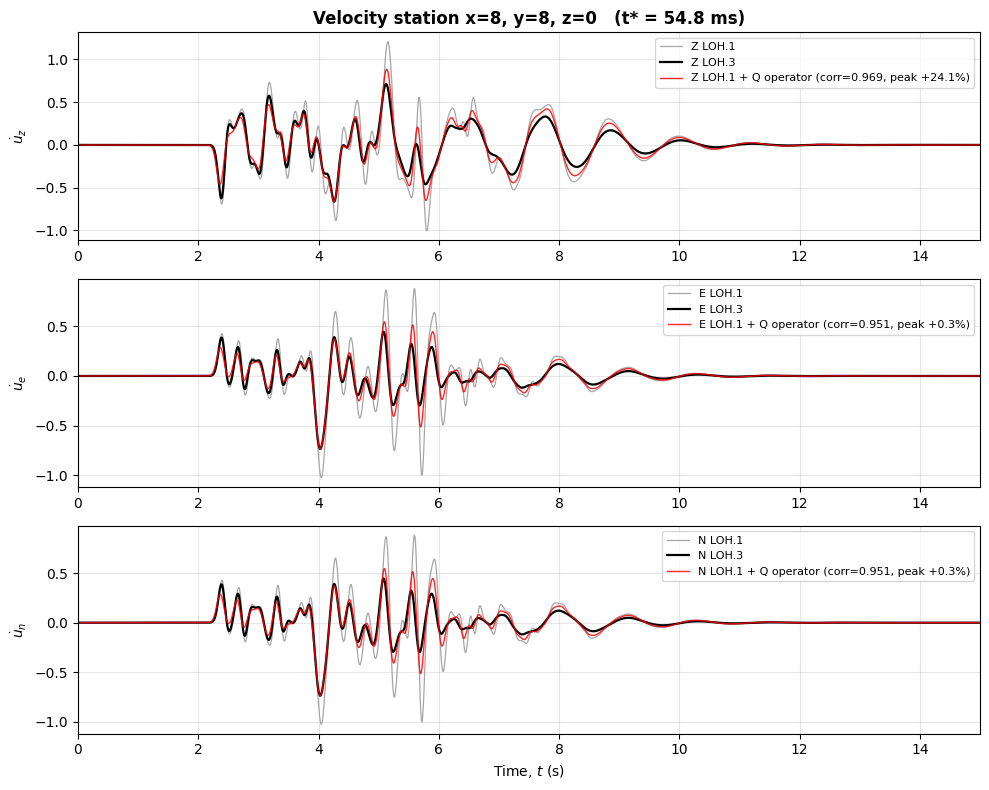

In [6]:
compare("sta01")

## 5. sta02, x=6, y=8, z=0

sta02 Z   corr = 0.972   peak error =  +15.6 %
sta02 E   corr = 0.975   peak error =   -1.2 %
sta02 N   corr = 0.963   peak error =  +18.2 %


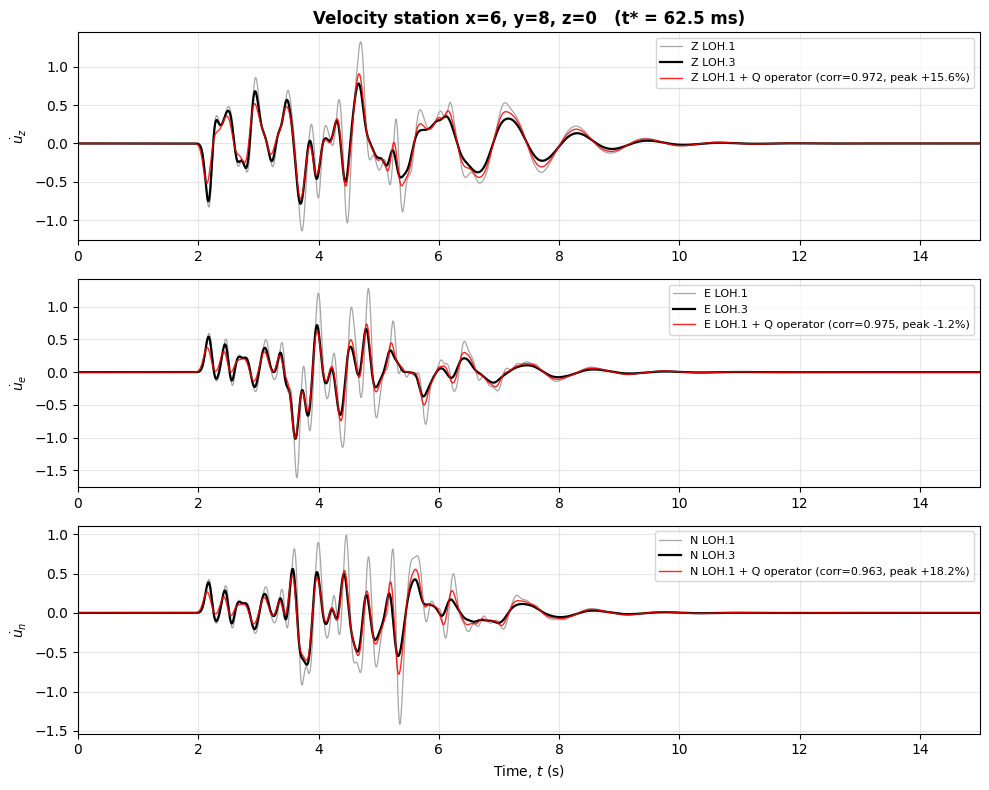

In [7]:
compare("sta02")

## 5. sta03, x=4, y=4, z=0.5

sta03 Z   corr = 0.988   peak error =   +0.8 %
sta03 E   corr = 0.988   peak error =   +3.0 %
sta03 N   corr = 0.988   peak error =   +3.0 %


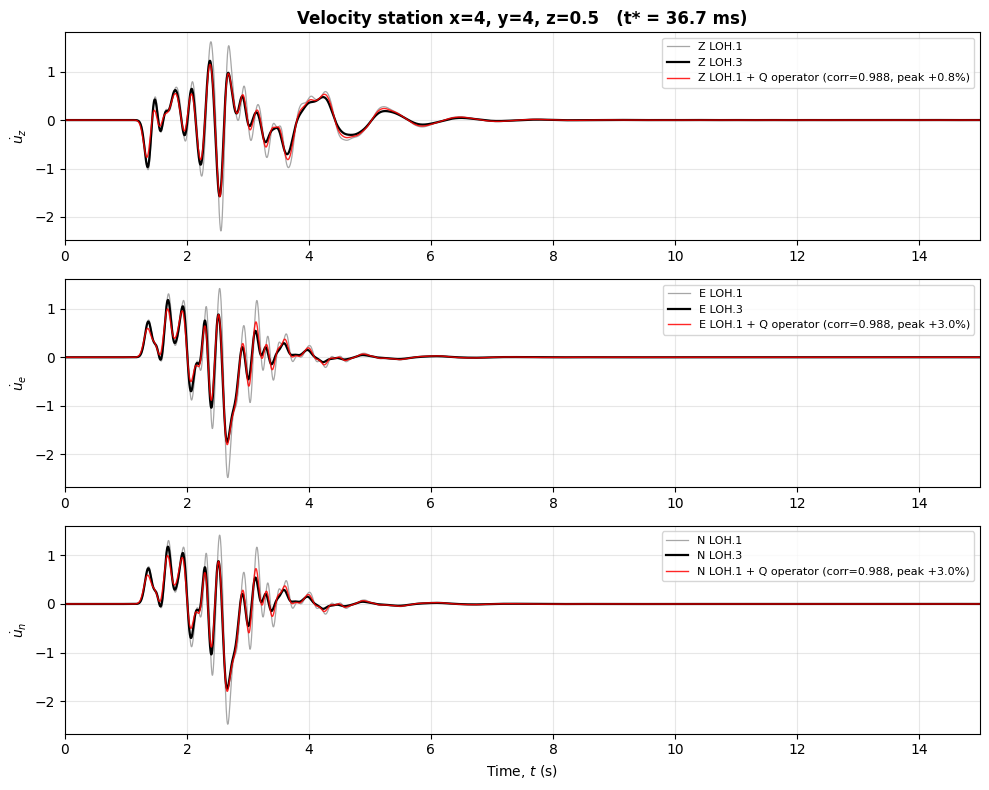

In [8]:
compare("sta03")

## 6. Result

| station | t* fit | t* ray | Z corr / peak | E corr / peak | N corr / peak |
|---|---|---|---|---|---|
| sta01 (8, 8, 0) | 54.8 ms | 95.7 ms | 0.969 / +24.1 % | 0.951 / +0.3 % | 0.951 / +0.3 % |
| sta02 (6, 8, 0) | 62.5 ms | 85.0 ms | 0.972 / +15.6 % | 0.975 / -1.2 % | 0.963 / +18.2 % |
| sta03 (4, 4, 0.5) | 36.7 ms | 40.6 ms | 0.988 / +0.8 % | 0.988 / +3.0 % | 0.988 / +3.0 % |

1. **The operator reproduces LOH.3 on every component**, correlation 0.95 to 0.99,
   against the untouched elastic traces that are far off in amplitude.
2. **Peak error is 0 to 24 %**, always an over-prediction: one `t*` slightly
   under-attenuates the phase that carries the peak.
3. **The spectral ratio is not a straight line.** It passes through zero at 0.1 to
   0.2 Hz, as it must, then drops fast towards 1 Hz and flattens above. Near 1 Hz the
   record is dominated by surface waves trapped in the slow Q = 40 layer, whose
   `t*` is about 10 km / (2.0 km/s x 40) = 125 to 140 ms; above that, body waves with
   a much smaller `t*` take over. The fit returns an average of the two, which is why
   it has a non-zero intercept and why it sits below the straight-ray value.
4. **Above about 12 Hz the ratio is meaningless**: LOH.1 (`dt = 0.005`) reaches a
   numerical floor while LOH.3 keeps falling. The fit stops at 10 Hz for that reason.

So a single `t*` is good for shape and good to about 20 % on peaks. When a number goes
into a report, re-run the model.